# Bonus 1

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def adaptive_euler_PI(f, t0, y0, tf, h0, tol):
    t = t0
    y = y0
    h = h0

    ts = [t]
    ys = [y]

    err_prev = tol
    kp = 0.7
    ki = 0.4

    fevals = 0

    while t < tf:

        if t + h > tf:
            h = tf - t

        # full step
        y1 = y + h*f(t, y)

        # two half steps
        yh = y + (h/2)*f(t, y)
        y2 = yh + (h/2)*f(t+h/2, yh)

        fevals += 3

        err = abs(y2 - y1)

        if err <= tol:
            t += h
            y = y2

            ts.append(t)
            ys.append(y)

            # PI controller
            factor = (tol/err)**kp * (err_prev/err)**ki
            h = 0.9*h*factor

            err_prev = max(err,1e-14)

        else:
            h = 0.9*h*(tol/err)**0.5

    return np.array(ts), np.array(ys), fevals

## Example Part 1: PI control reduced oscillations in step size and improved efficiency

In [17]:
def f(t,y):
    return -2*y

def exact_solution(t):
    return np.exp(-2*t)


t0 = 0
y0 = 1
tf = 5
h0 = 0.1
tol = 1e-4  

exact_y = exact_solution(tf)


t_pi, y_pi, fevals_pi = adaptive_euler_PI(f, t0, y0, tf, h0, tol)
error_pi = abs(y_pi[-1] - exact_y)

print("Part 1: Adaptive Euler PI Results")
print(f"Final time (t) reached: {t_pi[-1]:.5f}")
print(f"Estimated final y:      {y_pi[-1]:.8f}")
print(f"Exact final y:          {exact_y:.8f}")
print(f"Absolute Error:         {error_pi:.8e}")
print(f"Function evaluations:   {fevals_pi}\n")



Part 1: Adaptive Euler PI Results
Final time (t) reached: 5.00000
Estimated final y:      0.00000933
Exact final y:          0.00004540
Absolute Error:         3.60667082e-05
Function evaluations:   453



# Bonus 2

In [18]:
def adaptive_RK2(f, t0, y0, tf, h0, tol):
    t = t0
    y = y0
    h = h0

    ts = [t]
    ys = [y]

    fevals = 0

    while t < tf:

        if t + h > tf:
            h = tf - t

        k1 = f(t,y)
        y1 = y + h*k1

        k2 = f(t+h/2, y + h*k1/2)
        y2 = y + h*k2

        fevals += 2

        err = abs(y2-y1)

        if err <= tol:
            t += h
            y = y2
            ts.append(t)
            ys.append(y)

            h = 0.9*h*(tol/err)**0.5

        else:
            h = 0.9*h*(tol/err)**0.5

    return np.array(ts), np.array(ys), fevals

## Example Part 2: Embedded RK2 required fewer evaluations while achieving higher accuracy

In [19]:
def f(t,y):
    return -2*y

def exact_solution(t):
    return np.exp(-2*t)


t0 = 0
y0 = 1
tf = 5
h0 = 0.1
tol = 1e-4  

exact_y = exact_solution(tf)

t_rk2, y_rk2, fevals_rk2 = adaptive_RK2(f, t0, y0, tf, h0, tol)
error_rk2 = abs(y_rk2[-1] - exact_y)

print("Part 2: Adaptive RK2 Results")
print(f"Final time (t) reached: {t_rk2[-1]:.5f}")
print(f"Estimated final y:      {y_rk2[-1]:.8f}")
print(f"Exact final y:          {exact_y:.8f}")
print(f"Absolute Error:         {error_rk2:.8e}")
print(f"Function evaluations:   {fevals_rk2}")

Part 2: Adaptive RK2 Results
Final time (t) reached: 5.00000
Estimated final y:      0.00006001
Exact final y:          0.00004540
Absolute Error:         1.46108497e-05
Function evaluations:   328


In [25]:
tols = [1e-2,1e-3,1e-4,1e-5]

print("Tolerance | Euler Work | PI Work | RK2 Work | Euler Error | PI Error | RK2 Error")

work_euler=[]
err_euler=[]

work_PI=[]
err_PI=[]

work_RK2=[]
err_RK2=[]

for tol in tols:

    exact = exact_solution(5)

    # Euler
    t,y,w = adaptive_euler(f,0,1,5,0.1,tol)
    e1 = abs(y[-1]-exact)

    # PI Euler
    t,y,w2 = adaptive_euler_PI(f,0,1,5,0.1,tol)
    e2 = abs(y[-1]-exact)

    # RK2
    t,y,w3 = adaptive_RK2(f,0,1,5,0.1,tol)
    e3 = abs(y[-1]-exact)

    work_euler.append(w)
    err_euler.append(e1)

    work_PI.append(w2)
    err_PI.append(e2)

    work_RK2.append(w3)
    err_RK2.append(e3)

    print(f"{tol:.0e}      {w:8d}   {w2:8d}   {w3:8d}   {e1:.2e}   {e2:.2e}   {e3:.2e}")

Tolerance | Euler Work | PI Work | RK2 Work | Euler Error | PI Error | RK2 Error
1e-02            48         57         44   4.54e-05   1.46e-03   1.57e-03
1e-03           123        171        114   4.53e-05   4.42e-05   1.10e-04
1e-04           351        453        328   3.20e-05   3.61e-05   1.46e-05
1e-05          1068       1293       1004   1.47e-05   1.42e-05   1.93e-06


# Bonus 3

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def f(t,y):
    return -2*y

def exact_solution(t):
    return np.exp(-2*t)

def adaptive_euler(f,t0,y0,tf,h0,tol):

    t=t0
    y=y0
    h=h0
    fevals=0

    ts=[t]
    ys=[y]

    while t < tf:

        if t+h > tf:
            h=tf-t

        y1 = y + h*f(t,y)

        yh = y + (h/2)*f(t,y)
        y2 = yh + (h/2)*f(t+h/2,yh)

        fevals += 3

        err = abs(y2-y1)

        if err <= tol:
            t += h
            y = y2
            ts.append(t)
            ys.append(y)

        h = 0.9*h*(tol/(err+1e-14))**0.5

    return np.array(ts), np.array(ys), fevals


# PI Euler
def adaptive_euler_PI(f,t0,y0,tf,h0,tol):

    t=t0
    y=y0
    h=h0
    fevals=0

    ts=[t]
    ys=[y]

    err_prev = tol

    kp=0.7
    ki=0.4

    while t < tf:

        if t+h > tf:
            h=tf-t

        y1 = y + h*f(t,y)

        yh = y + (h/2)*f(t,y)
        y2 = yh + (h/2)*f(t+h/2,yh)

        fevals += 3

        err = abs(y2-y1)

        if err <= tol:
            t += h
            y = y2
            ts.append(t)
            ys.append(y)

            factor = (tol/(err+1e-14))**kp * (err_prev/(err+1e-14))**ki
            h = 0.9*h*factor

            err_prev = err
        else:
            h = 0.9*h*(tol/(err+1e-14))**0.5

    return np.array(ts), np.array(ys), fevals


# RK2
def adaptive_RK2(f,t0,y0,tf,h0,tol):

    t=t0
    y=y0
    h=h0
    fevals=0

    ts=[t]
    ys=[y]

    while t < tf:

        if t+h > tf:
            h=tf-t

        k1 = f(t,y)
        y1 = y + h*k1

        k2 = f(t+h/2, y+h*k1/2)
        y2 = y + h*k2

        fevals += 2

        err = abs(y2-y1)

        if err <= tol:
            t += h
            y = y2
            ts.append(t)
            ys.append(y)

        h = 0.9*h*(tol/(err+1e-14))**0.5

    return np.array(ts), np.array(ys), fevals

In [21]:
tols = [1e-2,1e-3,1e-4,1e-5]

work_euler = []
err_euler = []

work_PI = []
err_PI = []

work_RK2 = []
err_RK2 = []

for tol in tols:

    t,y,w = adaptive_euler(f,0,1,5,0.1,tol)
    exact = exact_solution(5)
    work_euler.append(w)
    err_euler.append(abs(y[-1]-exact))

    t,y,w = adaptive_euler_PI(f,0,1,5,0.1,tol)
    work_PI.append(w)
    err_PI.append(abs(y[-1]-exact))

    t,y,w = adaptive_RK2(f,0,1,5,0.1,tol)
    work_RK2.append(w)
    err_RK2.append(abs(y[-1]-exact))

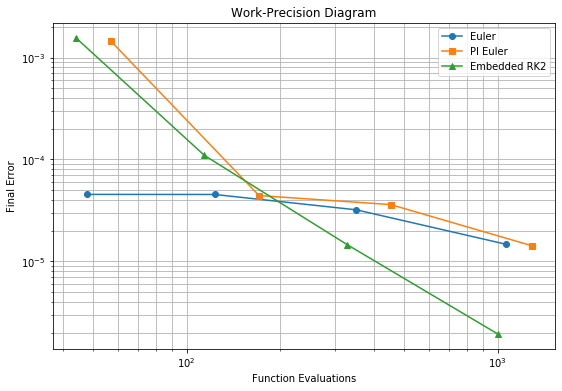

In [26]:
plt.figure(figsize=(9,6))

plt.loglog(work_euler, err_euler,'o-',label='Euler')
plt.loglog(work_PI, err_PI,'s-',label='PI Euler')
plt.loglog(work_RK2, err_RK2,'^-',label='Embedded RK2')

plt.xlabel("Function Evaluations")
plt.ylabel("Final Error")
plt.title("Work-Precision Diagram")
plt.grid(True, which='both')
plt.legend()
plt.show()

## Conclusions

PI controller reduced oscillations in step size and improved stability but the Embedded RK2 required fewer function evaluations than Euler while giving smaller error.

The work precision diagram shows RK2 is the most efficient method for tight tolerances but PI Euler performed better than standard adaptive Euler